## Installing Required Libraries

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

## Loading Dataset

In [5]:
df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Understanding Data

In [6]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Data Cleaning

In [7]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["race/ethnicity"] = le.fit_transform(df["race/ethnicity"])
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["lunch"] = le.fit_transform(df["lunch"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

## Exploratory Data Analysis

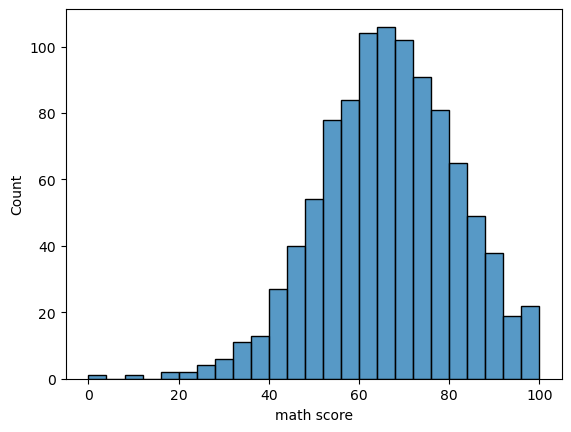

In [8]:
sns.histplot(df["math score"])
plt.show()

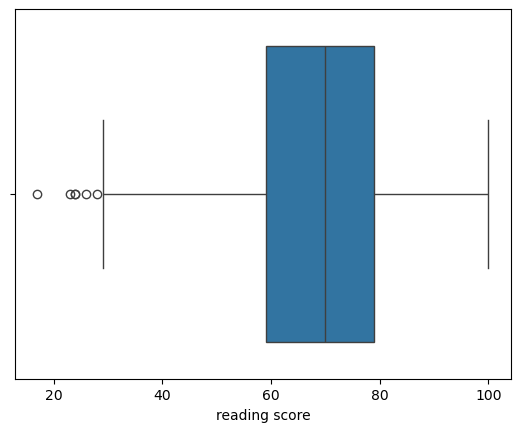

In [9]:
sns.boxplot(x=df["reading score"])
plt.show()

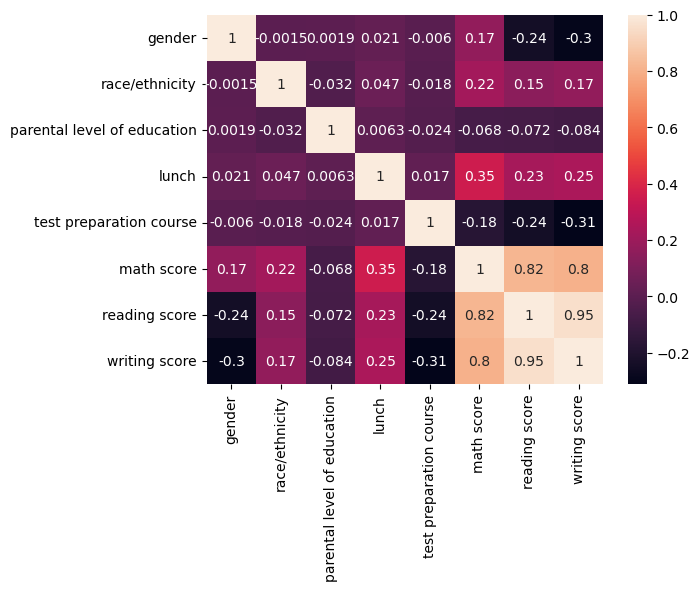

In [10]:
sns.heatmap(df.corr(),annot=True)
plt.show()

## Defining Problem

In [12]:
y=df["math score"]
X=df.drop("math score",axis=1)

## Split Data

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Training Model

In [14]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

## Prediction and Evaluation of Model

In [16]:
pred=model.predict(X_test)

mse=mean_squared_error(y_test,pred)
r2=r2_score(y_test,pred)
print("MSE:",mse)
print("R2 Score: ",r2)

MSE: 28.275284506327342
R2 Score:  0.8838026201112223
